In [54]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [5]:
data = pd.read_csv('data.csv')
data.head()

,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,feature_10,target
0,0.113768,0.930064,0.330528,0.010987,0.265703,0.699462,0.058465,0.431643,0.650958,0.751820,30.147094
1,0.380048,0.485946,0.870232,0.473401,0.454516,0.500864,0.471723,0.234329,0.072982,0.008372,21.424402
2,0.768462,0.217706,0.727438,0.718377,0.452155,0.434638,0.043989,0.972489,0.450133,0.378157,31.422056
3,0.606637,0.604335,0.540332,0.491236,0.325632,0.206348,0.825767,0.332475,0.955518,0.162811,31.308588
4,0.119770,0.469718,0.632829,0.504207,0.238259,0.452457,0.775360,0.174262,0.117621,0.218883,23.322751


In [75]:
model = LinearRegression()
X = data.drop(['target'], axis=1)
Y = data['target']

reg = model.fit(X, Y)
print(reg.intercept_)


4.373157038707124


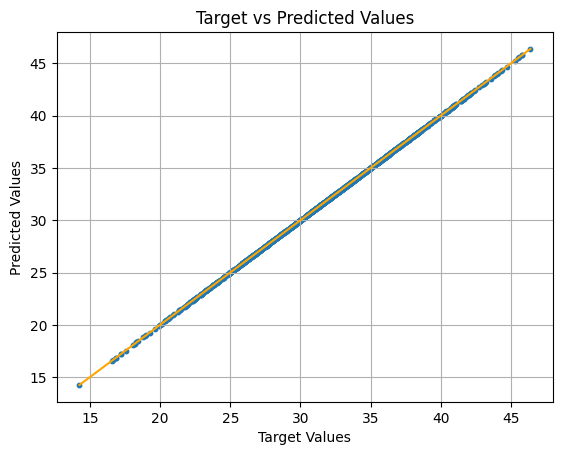

In [76]:
y_pred = reg.predict(X)

# Create scatter plot of target vs predicted values
plt.scatter(Y, y_pred, s=10)
plt.plot([Y.min(), Y.max()], [Y.min(), Y.max()], 'orange')
plt.xlabel("Target Values")
plt.ylabel("Predicted Values")
plt.title("Target vs Predicted Values")
plt.grid()
plt.show()

In [82]:
### Инициализируем точку для коэффициентов в виде вектора из единичек
initial_betas = np.ones(X.shape[1])
### Получим выражение выше для каждого объекта.
### Для этого скалярно перемножим строчки из X на наши beta
scalar_value = np.dot(X, initial_betas.reshape(-1, 1)).ravel()
scalar_value = (scalar_value - Y).values
scalar_value

array([-25.90369591, -17.47199067, -26.2585119 , -26.2574979 ,
       -19.6193853 , -28.64154272, -28.48242465, -25.13985495,
       -22.17970557, -24.77940736, -25.52603982, -23.84720822,
       -30.5415591 , -16.5775804 , -26.76644916, -19.21869239,
       -27.87680198, -23.86233818, -26.6154306 , -25.19557583,
       -22.54569936, -18.92362867, -15.53806922, -25.17909779,
       -23.51575002, -22.87821211, -34.56926473, -27.45784391,
       -22.12328657, -21.85761876, -28.46185319, -25.01068927,
       -23.77665145, -22.94501288, -33.50656386, -18.3234063 ,
       -29.49335591, -26.29355219, -21.41586375, -25.40415465,
       -23.95042836, -22.93499653, -27.8877486 , -24.79350083,
       -28.53243376, -25.42982514, -19.9960058 , -20.37480899,
       -20.75017561, -18.44457297, -25.30061742, -25.92896021,
       -23.29359986, -31.07745941, -20.92303014, -33.91668231,
       -25.55765132, -19.867261  , -18.93213682, -23.44340926,
       -20.47747076, -29.50104064, -31.38514217, -26.11

Теперь полученное значение для каждого объекта умножим на соответствующее значение признака $d_1$:

$$
d_{i1} \cdot (\beta_1 \cdot d_{i1} + ... + \beta_{n} \cdot d_{in} - y_i)
$$

In [83]:
### Возьмем столбик со значениями 1 признака
d_i1 = X.values[:, 0]
### Умножим каждый объект на соответствующее значение признака
scalar_value = scalar_value * d_i1
scalar_value

array([-2.94701446e+00, -6.64019582e+00, -2.01786666e+01, -1.59287653e+01,
       -2.34980948e+00, -2.03194721e+01, -9.99934717e+00, -1.02551234e+01,
       -2.01637786e+01, -2.22452912e+01, -2.92332565e+00, -9.62102324e+00,
       -2.14726754e+01, -7.22352557e+00, -2.32184311e+01, -1.86869802e+01,
       -9.49272206e+00, -5.79998011e+00, -2.45036007e+01, -1.53571918e+01,
       -1.38025119e+01, -1.79256163e+01, -1.07751724e+01, -2.34582155e+01,
       -8.59402054e+00, -1.50341602e+00, -7.59897339e+00, -1.73338324e+01,
       -1.47823690e+01, -1.82282109e+01, -2.37397306e+01, -1.77200609e+01,
       -7.48109339e+00, -1.94714931e+01, -5.93336039e+00, -1.52395908e+01,
       -2.36684262e+01, -1.51446737e+01, -3.62368048e+00, -1.87835317e+01,
       -2.27634091e+01, -2.00185071e+01, -1.24489460e+01, -1.29312241e+01,
       -1.43412565e+01, -2.15082136e+01, -8.33106207e+00, -1.57505967e+01,
       -1.36008610e+01, -8.74275066e-02, -1.81923254e+01, -2.27274501e+00,
       -8.24339269e+00, -

In [84]:
### Наконец, умножим все на 2 и усреднимся,
### чтобы получить значение производной по первому параметру

2 * np.mean(scalar_value)

np.float64(-27.62384887912409)

learn(self)

метод возвращает итоговую среднеквадратическую ошибку.
метод итеративно вычисляет среднеквадратическую ошибку и вектор-градиент. номер итерации и MSE записываются в словарь *iteration_loss_dict*. критерий останова срабатывает тогда, когда абсолютное значение разницы двух последних MSE меньше *self.threshold*.

In [36]:
class GradientDescentMse:
    """
    Базовый класс для реализации градиентного спуска в задаче линейной МНК регрессии
    """

    def __init__(self, samples: pd.DataFrame, targets: pd.DataFrame,
                 learning_rate: float = 1e-3, threshold = 1e-6, copy: bool = True):

        """
        self.samples - матрица признаков
        self.targets - вектор таргетов
        self.beta - вектор из изначальными весами модели == коэффициентами бета (состоит из единиц)
        self.learning_rate - параметр *learning_rate* для корректировки нормы градиента
        self.threshold - величина, меньше которой изменение в loss-функции означает остановку градиентного спуска
        iteration_loss_dict - словарь, который будет хранить номер итерации и соответствующую MSE
        copy: копирование матрицы признаков или создание изменения in-place
        """
        self.samples = samples.copy() if copy else samples
        self.targets = targets
        self.beta = np.ones(samples.shape[1])
        self.learning_rate = learning_rate
        self.threshold = threshold
        self.iteration_loss_dict = {}

    def add_constant_feature(self):
        """
        Метод для создания константной фичи в матрице объектов samples
        Метод создает колонку с константным признаком (interсept) в матрице признаков.
        Hint: так как количество признаков увеличилось на одну, не забудьте дополнить вектор с изначальными весами модели!
        """
        # Добавляем колонку с константным признаком (constant) в матрице признаков
        self.samples.insert(0, 'intercept', 1)
        # Дополняем вектор с изначальными весами модели
        self.beta = np.ones(self.samples.shape[1])


    def calculate_mse_loss(self) -> float:
        """
        Метод для расчета среднеквадратической ошибки

        :return: среднеквадратическая ошибка при текущих весах модели : float
        """
        y_pred = self.samples @ self.beta
        return ((y_pred - self.targets)**2).mean()
        # return np.mean((self.targets - y_pred) ** 2)



    def calculate_gradient(self) -> np.ndarray:
        """
        Метод для вычисления вектора-градиента
        Метод возвращает вектор-градиент, содержащий производные по каждому признаку.
        Сначала матрица признаков скалярно перемножается на вектор self.beta, и из каждой колонки
        полученной матрицы вычитается вектор таргетов. Затем полученная матрица скалярно умножается на матрицу признаков.
        Наконец, итоговая матрица умножается на 2 и усредняется по каждому признаку.
        :return: вектор-градиент, т.е. массив, содержащий соответствующее количество производных по каждой переменной : np.ndarray
        """
        y_pred = self.samples.dot(self.beta)
        errors = y_pred - self.targets
        # возвращает вектор-градиент, содержащий производные по каждому признаку.
        return 2 * self.samples.T.dot(errors) / self.samples.shape[0]


    def iteration(self):
        """
        Обновляем веса модели в соответствии с текущим вектором-градиентом
        """
        self.beta = self.beta - self.learning_rate * self.calculate_gradient()



    def learn(self):
        """
        Итеративное обучение весов модели до срабатывания критерия останова
        Запись mse и номера итерации в iteration_loss_dict

        Описание алгоритма работы для изменения бет:
            Фиксируем текущие beta -> start_betas
            Делаем шаг градиентного спуска
            Записываем новые beta -> new_betas
            Пока |L(new_beta) - L(start_beta)| >= threshold:
                Повторяем первые 3 шага

        Описание алгоритма работы для изменения функции потерь:
            Фиксируем текущие mse -> previous_mse
            Делаем шаг градиентного спуска
            Записываем новые mse -> next_mse
            Пока |(previous_mse) - (next_mse)| >= threshold:
                Повторяем первые 3 шага
        """

        iteration = 0
        previous_mse = self.calculate_mse_loss()   # начальное значение ошибки
        self.iteration_loss_dict[iteration] = previous_mse

        while True:
            # шаг градиентного спуска
            self.iteration()
            iteration += 1

            # новая ошибка
            next_mse = self.calculate_mse_loss()
            self.iteration_loss_dict[iteration] = next_mse

            # критерий останова
            if abs(previous_mse - next_mse) < self.threshold:
                break

            previous_mse = next_mse






Обучим коэффициенты линейной модели с помощью реализованного нами градиентного спуска, не забыв добавить свободную переменную. Получились ли такие же коэффициенты, как и при использовании **LinearRegression** из **sklearn**? Если нет, то почему они отличаются, на Ваш взгляд, и сильно ли?

In [51]:
GD = GradientDescentMse(X, Y)
GD.add_constant_feature()

GD.learn()


0      30.239780
1      21.561347
2      31.412301
3      31.312246
4      23.481275
         ...    
995    32.937818
996    27.507853
997    32.957319
998    34.136514
999    28.704965
Length: 1000, dtype: float64

In [52]:
gd_predict = GD.samples @ GD.beta
print(f'Веса для градиентного спуска: \n{GD.beta}')
print(f'Предсказание для градиентного спуска: \n{gd_predict}')

Веса для градиентного спуска: 
intercept     4.948547
feature_1     0.887333
feature_2     1.901007
feature_3     2.880636
feature_4     3.876626
feature_5     4.896235
feature_6     5.891262
feature_7     6.892548
feature_8     7.903119
feature_9     8.875801
feature_10    9.861096
dtype: float64
Предсказание для градиентного спуска: 
0      30.239780
1      21.561347
2      31.412301
3      31.312246
4      23.481275
         ...    
995    32.937818
996    27.507853
997    32.957319
998    34.136514
999    28.704965
Length: 1000, dtype: float64


### Анализ решения через LinearRegression s GradientDescentMse

In [53]:

linear_model = LinearRegression(fit_intercept=True)
predict = linear_model.fit(X, Y)
beta_lr_aug = linear_model.coef_
lr_predict = linear_model.predict(X)


array([30.14709445, 21.42440247, 31.4220562 , 31.30858777, 23.32275116,
       34.61716849, 33.84888083, 29.78356722, 27.49186002, 29.91500119,
       30.10506401, 28.17015244, 36.09153023, 19.96404312, 32.23293349,
       23.3763105 , 32.4230312 , 28.78694007, 32.11055821, 29.40091819,
       26.34010612, 22.57117016, 18.92421852, 30.46257066, 28.14745574,
       26.69887298, 40.27374008, 32.46089845, 27.30978145, 26.18110611,
       33.84104911, 30.31231444, 28.51473947, 27.53259714, 39.1527965 ,
       22.24491788, 35.01957779, 30.85502246, 25.06091013, 31.18508136,
       28.33006222, 26.67347052, 32.44949667, 30.22241795, 33.86485173,
       30.35232168, 24.00306478, 25.33614362, 24.75969895, 21.99310866,
       30.8778426 , 29.61174511, 27.65442265, 36.92302432, 25.59289845,
       40.57235204, 29.92157833, 23.11537439, 23.05867443, 27.73894164,
       24.58545467, 34.37587059, 37.01258922, 31.11207787, 30.91693006,
       29.6357749 , 35.37464434, 22.9865855 , 28.40995044, 39.24

In [57]:

mse_gd = mean_squared_error(Y, gd_predict)
mse_lr = mean_squared_error(Y, lr_predict)
r_gd  = r2_score(Y, gd_predict)
r_lr  = r2_score(Y, lr_predict)

print(f"MSE  GD: {mse_gd:.8f}   |  R GD: {r_gd:.6f}")
print(f"MSE  LR: {mse_lr:.8f}   |  R LR: {r_lr:.6f}")



MSE  GD: 0.01073274   |  R GD: 0.999660
MSE  LR: 0.00000000   |  R LR: 1.000000


#### Графики сравнение

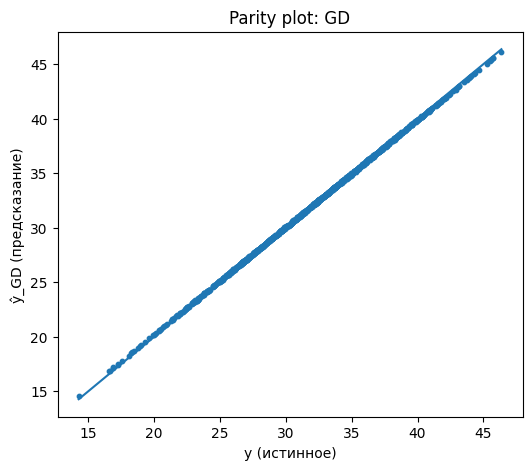

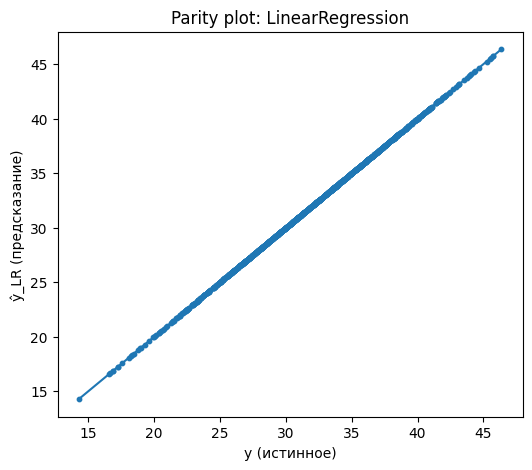

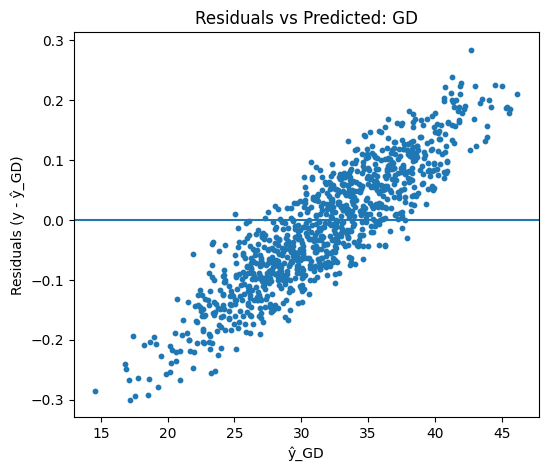

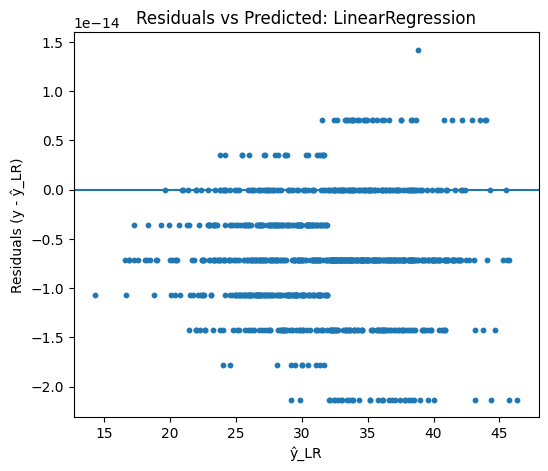

In [62]:
plt.figure(figsize=(6,5))
plt.scatter(Y, gd_predict, s=10)
miny, maxy = Y.min(), Y.max()
plt.plot([miny, maxy], [miny, maxy])
plt.xlabel("y (истинное)")
plt.ylabel("ŷ_GD (предсказание)")
plt.title("Parity plot: GD")
plt.show()

plt.figure(figsize=(6,5))
plt.scatter(Y, lr_predict, s=10)
miny, maxy = Y.min(), Y.max()
plt.plot([miny, maxy], [miny, maxy])
plt.xlabel("y (истинное)")
plt.ylabel("ŷ_LR (предсказание)")
plt.title("Parity plot: LinearRegression")
plt.show()

# 5.2 Остатки (residuals) — отдельно для каждой модели
res_gd = Y - gd_predict
res_lr = Y - lr_predict

plt.figure(figsize=(6,5))
plt.scatter(gd_predict, res_gd, s=10)
plt.axhline(0)
plt.xlabel("ŷ_GD")
plt.ylabel("Residuals (y - ŷ_GD)")
plt.title("Residuals vs Predicted: GD")
plt.show()

plt.figure(figsize=(6,5))
plt.scatter(lr_predict, res_lr, s=10)
plt.axhline(0)
plt.xlabel("ŷ_LR")
plt.ylabel("Residuals (y - ŷ_LR)")
plt.title("Residuals vs Predicted: LinearRegression")
plt.show()

GD:
- Точки лежат почти на диагонали → предсказания градиентного спуска очень близки к истинным значениям.
- Значит, модель обучилась и даёт хорошие прогнозы.

LinearRegression:
- Абсолютно та же картина: диагональ полностью совпадает с точками.
- Это эталонное решение, так как LR решает задачу аналитически через нормальные уравнения.
---
2 график

GD:
- Остатки (y - ŷ) не случайный шум, а имеют наклон (структуру).
- Видно, что ошибка систематически растёт/убывает в зависимости от предсказанного значения.
- Это говорит, что GD не дошёл до точного минимума, β ещё немного смещены.
- Поэтому у тебя остатки до 0.3 по масштабу.

LinearRegression:
- Остатки очень близки к нулю (уровень 1e-14 → машинная погрешность).
- Распределены без структуры.
- Это «идеальное» решение в пределах точности вычислений.

Установка `learning_rate` равным 1 может привести к слишком большим шагам градиентного спуска, в результате чего обучение может расходиться, а не сходиться к оптимальным коэффициентам. В итоге вектор-градиент станет слишком большим, и при обновлении коэффициентов будет происходить перепрыгивание оптимального значения. Таким образом, если `learning_rate` установлен на слишком большое значение, процесс оптимизации может не сойтись.

При установке значения `threshold` слишком малым, мы можем столкнуться с тем, что процесс оптимизации будет слишком долгим или вообще не завершится, потому что оптимизация остановится, когда разница между ошибкой на текущей и предыдущей итерациях будет меньше, чем установленный порог. Если установить этот порог слишком маленьким, то потребуется больше итераций для сходимости. Однако слишком большое значение порога может привести к тому, что процесс оптимизации не сойдется вообще, если слишком быстро сойдется в локальный минимум.

В машинном обучении зачастую исследуют так называемые **траектории обучения** (или **learning paths**). Это графики, показывающие, как во время обучения при каждой следующей итерации изменялось значение минимизируемого функционала. Постройте такие траектории для различных **learning rate**'ов и **threshold**'ов. Советуем использовать для этого разобранный на занятиях **add_subplot** метод.

Возьмите следующие **threshold**'ы: 1e-2, 1e-3, 1e-4, 1e-5

И следующие значения **learning rate**'а: 1e-1, 5e-2, 1e-2, 5e-3, 1e-3

У вас должен получиться примерно такой график (см. ниже, значения среднеквадратической ошибки мы намеренно замазали оранжевыми квадратиками, чтобы не спойлерить вам результаты).

Как и подобает хорошим Data Scientist'ам, не забывайте подписывать графики, оси, а так же делать элементы ваших визуализаций читаемыми и видимыми. Советуем пересмотреть методы и параметры форматирования из лекции.

При какой комбинации **threshold** - **learning rate** из возможных предложенных выше, получается достигнуть меньшего значения нашей минимизируемой функции? Запишите каждой из значений в легенде на графиках.


In [ ]:
learning_rates = [0.1, 0.05, 0.01, 0.005, 0.001]


import time

fig, axs = plt.subplots(len(thresholds), 1, figsize=(8, 16), sharex=True)
axs = np.atleast_1d(axs)  # чтобы удобно и при nrows=1

for i, threshold in enumerate(thresholds):
    ax = axs[i]
    xmax = 0
    ymax = 0.0

    for lr in learning_rates:
        gd = GradientDescentMse(X, Y, learning_rate=lr, threshold=threshold)
        gd.add_constant_feature()

        t0 = time.time()
        gd.learn()  # при желании: gd.learn(max_iters=200_000, by="loss")
        dt = time.time() - t0

        iters, losses = zip(*sorted(gd.iteration_loss_dict.items()))
        last_mse = losses[-1]

        ax.plot(iters, losses, label=f"lr={lr} | MSE={last_mse:.6f} | {dt:.2f}s")
        xmax = max(xmax, iters[-1])
        ymax = max(ymax, max(losses))

    ax.set_title(f"Convergence curves (threshold = {threshold})")
    ax.set_ylabel("MSE")
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0, 300)
    ax.set_ylim(0, max(1e-9, ymax))   # не обрезаем нули
    ax.legend(loc="upper right", fontsize=8)

axs[-1].set_xlabel("Iteration")

plt.tight_layout()
plt.show()
